## **Macroéconométrie : Relation empirique entre la croissance économique et le chômage à travers la loi d’Okun**
#### **TAPOAYI Inès**
---

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Introduction**

<p style="text-align: justify;">
La loi d'Okun décrit la relation empirique entre la croissance économique et la dynamique du chômage.

Développée par Arthur Okun (1962), cette théorie suggère qu'une croissance du PIB plus forte entraîne généralement une baisse du chômage, bien que cette relation ne soit ni parfaitement stable ni proportionnelle dans le temps.

Ce projet étudie la validité de la loi d'Okun à l'aide de séries temporelles macroéconomiques et d'analyses économétriques. L'objectif est d'évaluer l'influence de la croissance du PIB sur la dynamique du chômage au cours des cycles économiques.
</p>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Partie I**

1) Version en différence première de la loi d'Okun (1948-2022)

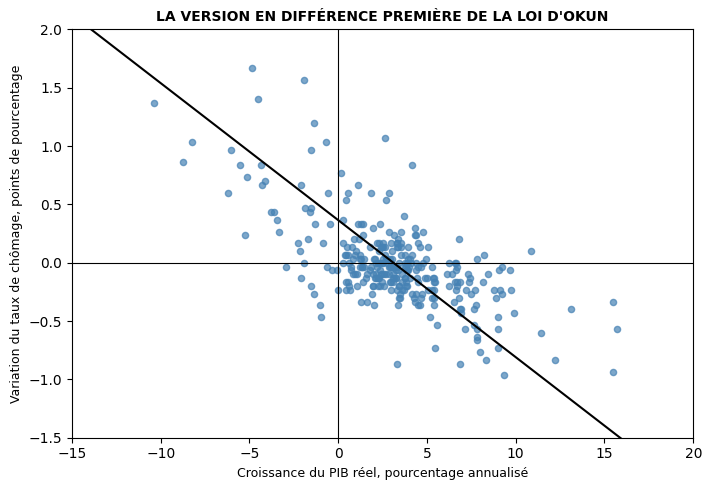

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Import des données
gdp = pd.read_csv("GDPC1.csv")
unrate = pd.read_csv("UNRATE.csv")

# Harmonisation des colonnes
gdp.rename(columns={"observation_date": "DATE"}, inplace=True)
unrate.rename(columns={"observation_date": "DATE"}, inplace=True)

# Conversion des dates
gdp["DATE"] = pd.to_datetime(gdp["DATE"])
unrate["DATE"] = pd.to_datetime(unrate["DATE"])

# PIB réel (croissance annualisée)
gdp = gdp.set_index("DATE").sort_index()
gdp["growth_ann"] = gdp["GDPC1"].pct_change() * 400
gdp.index = gdp.index.to_period("Q").to_timestamp("Q")

# Taux de chômage (moyenne trimestrielle)
unrate = unrate.set_index("DATE").sort_index()
unrate_q = unrate.resample("QE").mean()
unrate_q["delta_u"] = unrate_q["UNRATE"].diff()

# Fusion des séries
data = pd.merge(
    gdp[["growth_ann"]],
    unrate_q[["delta_u"]],
    left_index=True,
    right_index=True,
    how="inner"
).dropna()

data = data.loc["1948-06-30":]

# Régression linéaire
X = sm.add_constant(data["growth_ann"])
y = data["delta_u"]
model = sm.OLS(y, X).fit()

# Droite estimée
x_range = pd.Series(sorted(data["growth_ann"]))
y_pred = model.predict(sm.add_constant(x_range))

# Visualisation graphique
plt.figure(figsize=(7,5))
plt.scatter(data["growth_ann"], data["delta_u"], color="steelblue", s=20, alpha=0.7)
plt.plot(x_range, y_pred, color="black", linewidth=1.5)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.title("LA VERSION EN DIFFÉRENCE PREMIÈRE DE LA LOI D'OKUN", fontsize=10, fontweight="bold")
plt.xlabel("Croissance du PIB réel, pourcentage annualisé", fontsize=9)
plt.ylabel("Variation du taux de chômage, points de pourcentage", fontsize=9)
plt.grid(False)
plt.tight_layout()
plt.xlim(-15, 20)
plt.ylim(-1.5, 2)
plt.show()

2. Estimation de la version en différence première de la loi d'Okun (périodes 1948-Q2 à 1960-Q4 et 1948-Q2 à 2019-Q4)


=============== Estimation de la loi d'Okun (1948Q2–1960Q4) ===============

                            OLS Regression Results                            
Dep. Variable:                delta_u   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     73.46
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           2.59e-11
Time:                        20:28:27   Log-Likelihood:                -21.088
No. Observations:                  51   AIC:                             46.18
Df Residuals:                      49   BIC:                             50.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

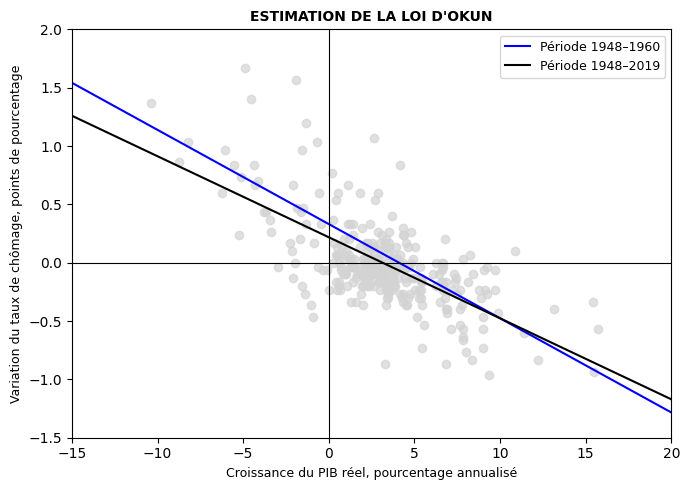

In [2]:
period1 = data.loc["1948-06-30":"1960-12-31"]
period2 = data.loc["1948-06-30":"2019-12-31"]

# Fonction d’estimation de la loi d’Okun
def okun_regression(df, label):
    X = sm.add_constant(df["growth_ann"])
    y = df["delta_u"]
    model = sm.OLS(y, X).fit()

    print("\n" + "="*75)
    print(f" Estimation de la loi d'Okun ({label}) ".center(75, "="))
    print("="*75 + "\n")

    print(model.summary())
    print(f"\nCoefficient d'Okun (β) = {model.params['growth_ann']:.4f}")
    print(f"Constante (α) = {model.params['const']:.4f}")
    print(f"R² = {model.rsquared:.3f}")
    print(f"N = {int(model.nobs)}")
    print("="*75)
    return model.params["growth_ann"], model.params["const"]

# Estimations 
beta1, alpha1 = okun_regression(period1, "1948Q2–1960Q4")
beta2, alpha2 = okun_regression(period2, "1948Q2–2019Q4")

# Visualisation graphique
x_range = pd.Series(sorted(data["growth_ann"]))
y_pred1 = alpha1 + beta1 * x_range
y_pred2 = alpha2 + beta2 * x_range

plt.figure(figsize=(7,5))
plt.scatter(
    data["growth_ann"], data["delta_u"],
    color="lightgray", alpha=0.7
)
plt.plot(x_range, y_pred1, color="blue", linewidth=1.5, label="Période 1948–1960")
plt.plot(x_range, y_pred2, color="black", linewidth=1.5, label="Période 1948–2019")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.title("ESTIMATION DE LA LOI D'OKUN", fontsize=10, fontweight="bold")
plt.xlabel("Croissance du PIB réel, pourcentage annualisé", fontsize=9)
plt.ylabel("Variation du taux de chômage, points de pourcentage", fontsize=9)
plt.legend(fontsize=9)
plt.xlim(-15, 20)
plt.ylim(-1.5, 2)
plt.tight_layout()
plt.show()

3) Estimation du coefficient d'Okun (régressions glissantes sur la période 1948-2022)

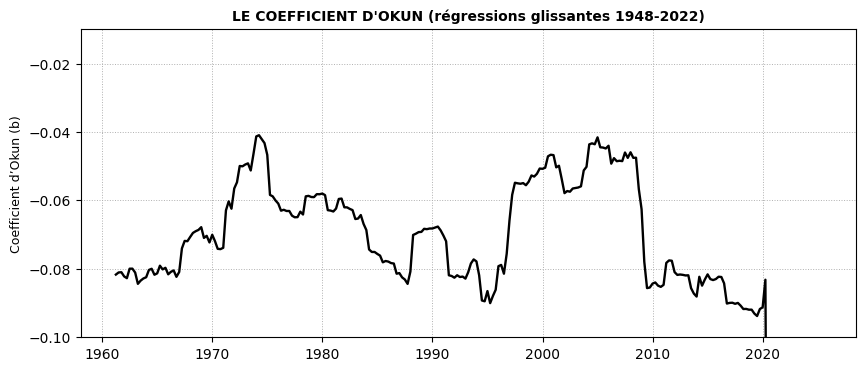

In [2]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Import des données
gdp = pd.read_csv("GDPC1.csv")
unrate = pd.read_csv("UNRATE.csv")

# Harmonisation des colonnes
gdp.rename(columns={"observation_date": "DATE"}, inplace=True)
unrate.rename(columns={"observation_date": "DATE"}, inplace=True)

# Conversion des dates
gdp["DATE"] = pd.to_datetime(gdp["DATE"])
unrate["DATE"] = pd.to_datetime(unrate["DATE"])

# PIB réel 
gdp = gdp.set_index("DATE").sort_index()
gdp["dGDP"] = 400 * np.log(gdp["GDPC1"] / gdp["GDPC1"].shift(1))
gdp.index = gdp.index.to_period("Q").to_timestamp("Q")

# Taux de chômage
unrate = unrate.set_index("DATE").sort_index()
unrate_q = unrate.resample("QE").mean()
unrate_q["dU"] = unrate_q["UNRATE"].diff()
unrate_q.index = unrate_q.index.to_period("Q").to_timestamp("Q")

# Fusion des séries
data = pd.merge(
    gdp[["dGDP"]],
    unrate_q[["dU"]],
    left_index=True,
    right_index=True,
    how="inner"
).dropna()

# Régression glissante
window = 52
okun_b, dates = [], []

for i in range(window, len(data)):
    subset = data.iloc[i-window:i]
    X = sm.add_constant(subset["dGDP"])
    y = subset["dU"]
    model = sm.OLS(y, X).fit()
    okun_b.append(model.params["dGDP"])
    dates.append(subset.index[-1])

# Visualisation graphique
plt.figure(figsize=(10,4))
plt.plot(dates, okun_b, color='black', linewidth=1.7)
plt.title("LE COEFFICIENT D'OKUN (régressions glissantes 1948-2022)", fontsize=10, fontweight="bold")
plt.ylabel("Coefficient d’Okun (b)", fontsize=9)
plt.grid(True, linestyle=':', linewidth=0.7)
plt.ylim(-0.10, -0.01)
plt.show()

4) Coefficient d'Okun et cycle économique (1948-2022)

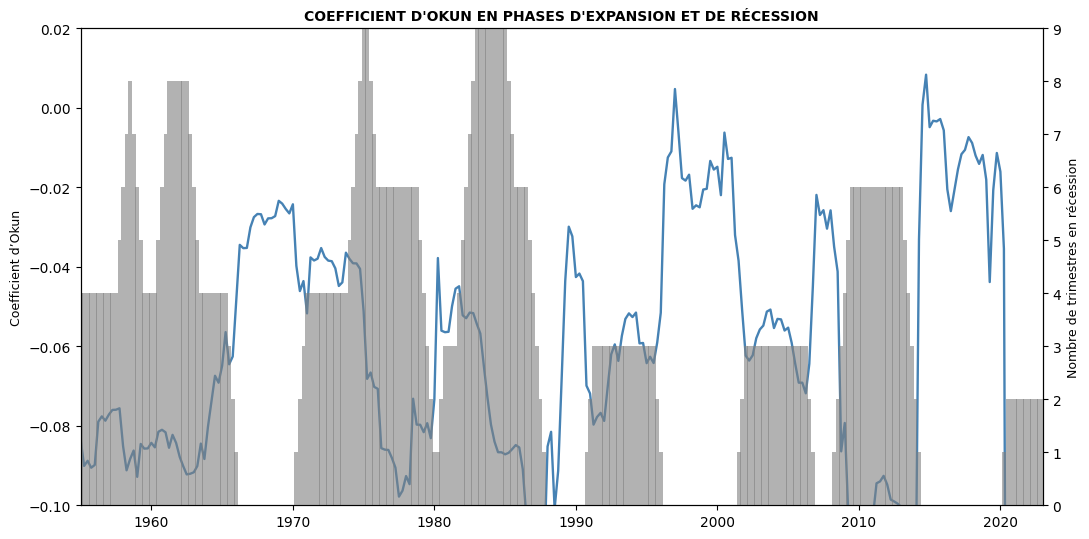

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Import des données
gdp = pd.read_csv("GDPC1.csv")
unrate = pd.read_csv("UNRATE.csv")
usrec = pd.read_csv("USREC.csv")

# Harmonisation des données
for df in [gdp, unrate, usrec]:
    df.rename(columns={"observation_date": "DATE"}, inplace=True)
    df["DATE"] = pd.to_datetime(df["DATE"])

# PIB réel (croissance trimestrielle annualisée)
gdp = gdp.set_index("DATE").sort_index()
gdp["dGDP"] = 400 * np.log(gdp["GDPC1"] / gdp["GDPC1"].shift(1))
gdp.index = gdp.index.to_period("Q").to_timestamp("Q")

# Taux de chômage trimestriel
unrate = unrate.set_index("DATE").sort_index()
unrate_q = unrate.resample("QE").mean()
unrate_q["dU"] = unrate_q["UNRATE"].diff()
unrate_q.index = unrate_q.index.to_period("Q").to_timestamp("Q")

# Récessions trimestrielles (NBER)
usrec = usrec.set_index("DATE").sort_index()
usrec_q = usrec.resample("QE").max()
usrec_q.index = usrec_q.index.to_period("Q").to_timestamp("Q")

# Fusion des séries
data = gdp[["dGDP"]].merge(unrate_q[["dU"]], left_index=True, right_index=True, how="outer")
data = data.merge(usrec_q, left_index=True, right_index=True, how="outer")
data.rename(columns={"USREC": "recession"}, inplace=True)
data = data.dropna(subset=["dGDP", "dU", "recession"])

# Régressions glissantes sur 5 ans
window = 20
okun_b, rec_quarters, dates = [], [], []

for i in range(window, len(data)):
    subset = data.iloc[i-window:i]
    X = sm.add_constant(subset["dGDP"])
    y = subset["dU"]
    model = sm.OLS(y, X).fit()
    okun_b.append(model.params["dGDP"])
    rec_quarters.append(int(subset["recession"].sum()))
    dates.append(subset.index[-1])

# Visualisation graphique
fig, ax1 = plt.subplots(figsize=(11,5.5))
ax1.plot(dates, okun_b, color='steelblue', linewidth=1.7)
ax1.set_ylabel("Coefficient d’Okun", fontsize=9)
ax1.set_ylim(-0.1, 0.02)
ax1.set_xlim(pd.Timestamp("1955-01-01"), pd.Timestamp("2022-12-31"))
ax1.tick_params(axis='y')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(dates, rec_quarters, width=100, color='gray', alpha=0.6, align='center')
ax2.set_ylabel("Nombre de trimestres en récession", fontsize=9)
ax2.set_ylim(0, 9)
ax2.tick_params(axis='y')

plt.title("COEFFICIENT D'OKUN EN PHASES D'EXPANSION ET DE RÉCESSION", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Partie II**

<p style="text-align: justify;">
Le phénomène d’hystérèse désigne la persistance d’un phénomène alors que les causes initiales qui l’ont fait apparaître ont disparu (Blanchard et Summers, 1986). En ce sens, le chômage, à l’origine conjoncturel, pourrait se transformer en chômage structurel même si la cause initiale du chômage conjoncturel a disparu. Le chômage de longue durée, représentant les personnes en situation de chômage depuis plus d’un an, reflète les effets d’hystérèse du chômage. Plus le chômage est long, plus la probabilité de sortie du chômage est faible. Cela s’explique notamment par la diminution de l’employabilité, les comportements de découragement et de retrait du marché du travail des demandeurs d’emploi ainsi que du comportement sélectif des employeurs (Blanchard et
Diamond, 1994).
</p>

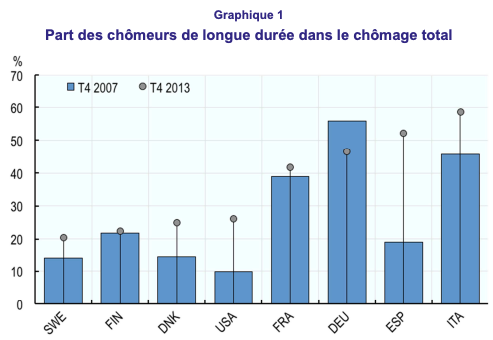

*Source : OCDE*

<p style="text-align: justify;">
Le graphique montre un accroissement de la part des chômeurs de longue durée dans le chômage total pour la grande majorité des pays étudiés sur la période de 2007 à 2013. Il permet de faire un parallèle entre les niveaux d’avant et d’après crise financière de 2008. On note des différences dans l’ampleur des retombées de la crise sur le marché du travail. Certains pays, comme l’Allemagne, la France et l’Italie, enregistraient déjà une part élevée de chômeurs de longue durée (40 % à 60%). D’autres pays, tels que l’Espagne et les États-Unis, ont vu leur part de chômeurs de longue durée, initialement faible (10% à 20%), plus que doubler sur la période. La hausse du chômage de longue durée peut être expliquée par des reprises sans emploi. Plus la reprise est lente, plus le pays s’expose à des effets d’hystérèse.
</p>

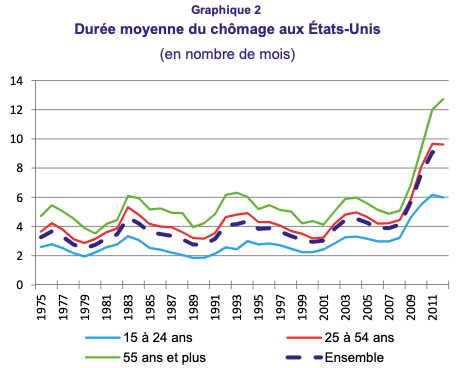

*Source : OCDE*

<p style="text-align: justify;">
Le graphique affiche l’évolution de la durée moyenne du chômage par tranche d’âge aux États-Unis. Sur l’ensemble de la période, on constate que plus l’individu est âgé, plus sa période de chômage sera longue. Depuis la crise de 2008, on constate une augmentation significative de la durée moyenne du chômage, tous âges confondus. Le premier graphique a en effet révélé le fort impact de la crise sur la part de chômeurs de longue durée dans le chômage total aux États-Unis. La raréfaction des postes en cas d’augmentation du chômage a tendance à défavoriser ceux qui sont les plus éloignés de l’outil de production. L’écart entre la tranche 25-54 ans et la tranche 55 ans et plus se creuse au fil du temps. La durée moyenne du chômage des personnes de 55 ans et plus a franchi le seuil des 12 mois en fin de période. En d’autres termes, les individus de 55 ans et plus sont en moyenne des chômeurs de longue durée.
</p>

<p style="text-align: justify;">
L’étude confirme l’existence de phénomène d’hystérèse en France. Le niveau du chômage de longue durée impacte de manière durable celui du chômage global, et par conséquent celui du chômage structurel. Il constitue alors un facteur explicatif de l’hystérèse. Depuis la crise de 2008, dans le cas de la France notamment, la relation entre chômage de longue durée et croissance s’est inversée. Le chômage de longue durée a un impact durable sur la croissance, donc sur la croissance tendancielle. Cet effet est lié au découragement des demandeurs d’emploi, pouvant être mesuré indirectement en France par la diminution de la population active.
</p>

<p style="text-align: justify;">
Le modèle autorégressif (AR) suppose implicitement l’exogénéité du chômage de longue durée. Autrement dit, le chômage de longue durée influence le chômage global. En réalité, le chômage de longue durée et le chômage global peuvent s’influencer mutuellement. En conséquence, les auteurs ont recours au modèle vectoriel autorégressif (VAR) pour permettre l’étude de la dynamique des deux types de chômage, considérés donc comme endogènes.
</p>

<p style="text-align: justify;">
Depuis la crise financière, le chômage de longue durée a progressé en France, comme dans la grande majorité des pays membres de l’Union Européenne (UE), et aux États-Unis très nettement. Entre 2008 et 2016, le taux de chômage de longue durée est passé de 2,8% à 4,3% en France et de 2,6% à 4,2% au sein de l’UE. La part de chômeurs de longue durée a augmenté de façon moins marquée en France que dans l’UE (36 % à 41% contre 37% à 50%). La situation actuelle de la France reste cependant plus dégradée que celle des États-Unis. En effet, le pays affiche un taux de chômage de longue durée de seulement 1,2% de la population active, soit près de 4 fois celui de la France.
</p>

<p style="text-align: justify;">
L’étude a fait naître des a priori concernant les relations de long terme. L’analyse mesure l’impact du chômage de longue durée sur la croissance tendancielle, mais pas sur la croissance potentielle qui est une variable inobservable. Cette variable doit donc être estimée. Les auteurs suggèrent l’utilisation de la fonction de production avec la décomposition cycle/tendance des facteurs de production (main-d’œuvre, capital, technologie) pour expliquer les effets structurels du chômage. Dans une perspective de moyen terme, les auteurs envisagent de prendre en compte comme variables explicatives les conditions de financement de l’économie, pouvant agir sur la création d’emplois et l’investissement productif. Enfin, une étude sectorielle permettrait, selon eux, de mieux tenir compte de l’hétérogénéité des chômeurs et d’identifier les mécanismes économiques propres à chaque secteur d’activité.
</p>

***Estimations sur la période 1980-2020 pour la série réelle du chômage et la série désagrégée du chômage de long terme***

5. Dynamique autorégressive du taux de croissance du nombre de chômeurs parmi les 15-64 ans 

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
import matplotlib.pyplot as plt

# Lecture des fichiers csv
chomage = pd.read_csv("chomage_1564.csv", sep=';', decimal=',', dtype=str)
lt = pd.read_csv("chomage_LT.csv", sep=';', decimal=',', dtype=str)
pib = pd.read_csv("PIB.csv", sep=';', decimal=',', dtype=str)

# Nettoyage et formatge des données
def clean_number(x):
    if isinstance(x, str):
        x = x.replace(" ", "").replace(",", ".")
    return pd.to_numeric(x, errors='coerce')

chomage['Cho1564'] = chomage['Cho1564'].apply(clean_number)
lt['ChoLT'] = lt['ChoLT'].apply(clean_number)
pib['Y'] = pib['Y'].apply(clean_number)

chomage['Year'] = pd.to_numeric(chomage['Time period'].str.extract(r'(\d{4})')[0], errors='coerce')
lt['Year'] = pd.to_numeric(lt['Time period'].str.extract(r'(\d{4})')[0], errors='coerce')
pib['Year'] = pd.to_numeric(pib['Time period'].str.extract(r'(\d{4})')[0], errors='coerce')

chomage = chomage.dropna(subset=['Year'])
lt = lt.dropna(subset=['Year'])
pib = pib.dropna(subset=['Year'])

# Agrégation annuelle du PIB
pib_annual = pib.groupby('Year')['Y'].mean().reset_index().rename(columns={'Y':'PIB_annual'})

# Fusion des séries
df = pd.merge(chomage[['Year', 'Cho1564']], lt[['Year', 'ChoLT']], on='Year', how='inner')
df = pd.merge(df, pib_annual, on='Year', how='left')
df = df.sort_values('Year').reset_index(drop=True)

# Variables log et différenciées
df['lcho1564'] = np.log(df['Cho1564'])
df['lchoLT'] = np.log(df['ChoLT'])
df['dlog_cho1564'] = df['lcho1564'].diff()
df['dlog_choLT'] = df['lchoLT'].diff()
df = df.dropna().reset_index(drop=True)

# Tableau 1 : AR(4)
y = df['dlog_cho1564']
model1 = AutoReg(y, lags=4, old_names=False).fit()
print("\n" + "="*80)
print("TABLEAU 1 : Dynamique autorégressive du taux de croissance du chômage 15-64 ans".center(80))
print("="*80 + "\n")
print(model1.summary())


TABLEAU 1 : Dynamique autorégressive du taux de croissance du chômage 15-64 ans 

                            AutoReg Model Results                             
Dep. Variable:           dlog_cho1564   No. Observations:                   40
Model:                     AutoReg(4)   Log Likelihood                  35.510
Method:               Conditional MLE   S.D. of innovations              0.090
Date:                Thu, 16 Oct 2025   AIC                            -59.020
Time:                        06:42:08   BIC                            -49.519
Sample:                             4   HQIC                           -55.704
                                   40                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0046      0.016      0.294      0.769      -0.026       0.035
dlog_cho1564.L1     0.4995      0

6. Dynamique autorégressive du taux de croissance du nombre de chômeurs de longue durée 

In [8]:
# Tableau 2 : AR avec V lag1
df['V'] = df['lcho1564'] * df['lchoLT']
df['V_lag1'] = df['V'].shift(1)

df['dlog_cho1564_L1'] = df['dlog_cho1564'].shift(1)
df['dlog_cho1564_L2'] = df['dlog_cho1564'].shift(2)
df['dlog_cho1564_L4'] = df['dlog_cho1564'].shift(4)

df2 = df.dropna(subset=['V_lag1','dlog_cho1564_L1','dlog_cho1564_L2','dlog_cho1564_L4'])

X = df2[['dlog_cho1564_L1','dlog_cho1564_L2','dlog_cho1564_L4','V_lag1']]
X = sm.add_constant(X)
y = df2['dlog_cho1564']

model2 = sm.OLS(y, X).fit()
print("\n" + "="*75)
print("TABLEAU 2 : Dynamique autorégressive du taux de croissance du chômage LT".center(75))
print("="*75 + "\n")
print(model2.summary())


  TABLEAU 2 : Dynamique autorégressive du taux de croissance du chômage LT 

                            OLS Regression Results                            
Dep. Variable:           dlog_cho1564   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     4.367
Date:                Thu, 16 Oct 2025   Prob (F-statistic):            0.00646
Time:                        06:46:37   Log-Likelihood:                 38.148
No. Observations:                  36   AIC:                            -66.30
Df Residuals:                      31   BIC:                            -58.38
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

7. Équation de long terme reliant le nombre de chômeurs entre 15 et 64 ans (en logarithme) au nombre de chômeurs de longue durée (en logarithme)

In [6]:
# Tableau 3 : Cointégration (Johansen)
data_coint = df[['lcho1564','lchoLT']].dropna()
jres = coint_johansen(data_coint, det_order=0, k_ar_diff=1)
print("\n" + "="*85)
print("TABLEAU 3 : Équation reliant le nombre de chômeurs 15-64 ans au nombre de chômeurs LT".center(85))
print("="*85 + "\n")
print("Valeurs propres :", jres.eig)
print("Statistiques de trace :", jres.lr1)
print("Valeurs critiques 5% :", jres.cvt[:,1])


TABLEAU 3 : Équation reliant le nombre de chômeurs 15-64 ans au nombre de chômeurs LT

Valeurs propres : [0.28391649 0.1326343 ]
Statistiques de trace : [18.09761676  5.40719435]
Valeurs critiques 5% : [15.4943  3.8415]


8. Estimation de la dynamique à correction d’erreur des fluctuations du taux de croissance du chômage global 

In [9]:
# Tableau 4 : VECM
df['dlog_cho1564'] = df['lcho1564'].diff()
df['dlog_chold'] = df['lchoLT'].diff()
df['Z_lag1'] = (df['lcho1564'] - df['lchoLT'] + 0.7).shift(1)

df['dlog_cho1564_L1'] = df['dlog_cho1564'].shift(1)
df['dlog_cho1564_L2'] = df['dlog_cho1564'].shift(2)
df['dlog_chold_L1'] = df['dlog_chold'].shift(1)
df['dlog_chold_L4'] = df['dlog_chold'].shift(4)

df4 = df.dropna(subset=['Z_lag1','dlog_cho1564_L1','dlog_cho1564_L2','dlog_chold_L1','dlog_chold_L4'])
X = df4[['Z_lag1','dlog_cho1564_L1','dlog_cho1564_L2','dlog_chold_L1','dlog_chold_L4']]
X = sm.add_constant(X)
y = df4['dlog_cho1564']
model4 = sm.OLS(y, X).fit()
print("\n" + "="*65)
print("TABLEAU 4 : Estimation de la dynamique à correction d’erreur".center(65))
print("="*65 + "\n")
print(model4.summary())


   TABLEAU 4 : Estimation de la dynamique à correction d’erreur  

                            OLS Regression Results                            
Dep. Variable:           dlog_cho1564   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     7.071
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           0.000198
Time:                        06:57:30   Log-Likelihood:                 44.547
No. Observations:                  35   AIC:                            -77.09
Df Residuals:                      29   BIC:                            -67.76
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------